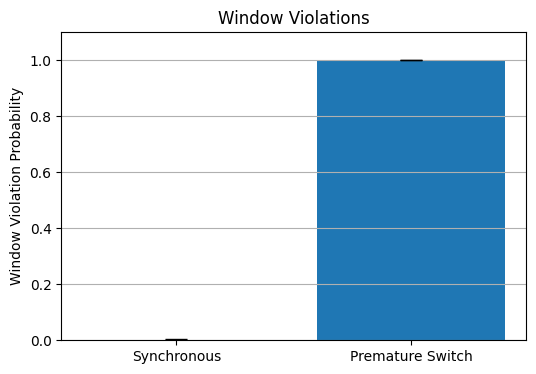

In [2]:
# {'N': 1000, 'window_violation_probability': 0.002, 'ci_lower': -0.0007690853363520596, 'ci_upper': 0.00476908533635206, 'mean_deadline_miss': 0.0, 'mean_interrupt': 0.0}
import matplotlib.pyplot as plt

labels = ["Synchronous", "Premature Switch"]

prob = [0.002, 1.0]

ci_lower = [-0.0007690853363520596, 1.0]
ci_upper = [0.00476908533635206, 1.0]

err_lower = [p - l for p, l in zip(prob, ci_lower)]
err_upper = [u - p for p, u in zip(prob, ci_upper)]

plt.figure(figsize=(6,4))

plt.bar(labels, prob, yerr=[err_lower, err_upper], capsize=8)

plt.ylabel("Window Violation Probability")
plt.title("Window Violations")

plt.ylim(0,1.1)

plt.grid(axis='y')

plt.show()

## Use Case: Single Inverted Pendulum on Cart
We consider a system of inverted pendulum on a cart, we assume the system operates in certain modes of operation to achieve the desired behaviour for that mode. 
Let the modes of operation be `m1` and `m2`, where the system operates at a sampling interval of `T=20ms` and `T=10ms` respectively. 
It is guaranteed that there exists a valid schedule $\tau$ that ensures the stability of the system by closing the control loop. 
From the spectral analysis, we were able to derive the robustness of the system to disturbance. We can state that there is a maximum consecutive deadline the system can
tolerate before becoming unstable for a given schedule $\tau$. 


$$\tau \vdash \langle n \rangle$$


where n is maximum consecutive deadline the system can miss. 

Sequence of operations: 
### Case 1: Pendulum operates in mode 1 for the entire life cycle 

h1 = 20ms
K1 = [-0.866502 	-1.688026 	-18.727439 	-3.592953]
n1 = 9

### Case 2: Aggressive mode for the entire life time

h2 = 10ms
K2 = [-23.770885, 	-21.232774, 	-88.144034, 	-18.446548]
n2 = 6

### Case 3: Premature switch
The system switches the mode of operation from m1 -> m2 at time t1 before the network configurations are ready.
The time taken for the network reconfig be $\delta_{nrc}$. We assume that the mode $m1$ has a valid schedule $\tau_1$
and `m2` has a valid schedule $\tau_2$. The premature switch of application mode results in an unstable system if
$\delta_{nrc} > n_2 \cdot h_2$

$$\delta_{nrc} \leq n_2 \cdot h_2$$

Alternatively, the safety condition:

$$\left\lceil \frac{\delta_{nrc}}{h_2} \right\rceil > n_2$$

### Case 4: Sync Switch
The system switches the mode of operation from m1 -> m2 at time t1 then the application and network switch modes only at synchronized time t2,  where t2 is the hypercycle of the sampling periods of modes.

### General Case
Let us assume a system with a set of modes of operations M = {m1, m2.. mn} then 

Found 4 state files:
  results/single_pendulum_cart/agg_mode_states.csv
  results/single_pendulum_cart/delayed_switch_states.csv
  results/single_pendulum_cart/normal_mode_states.csv
  results/single_pendulum_cart/sync_switch_states.csv


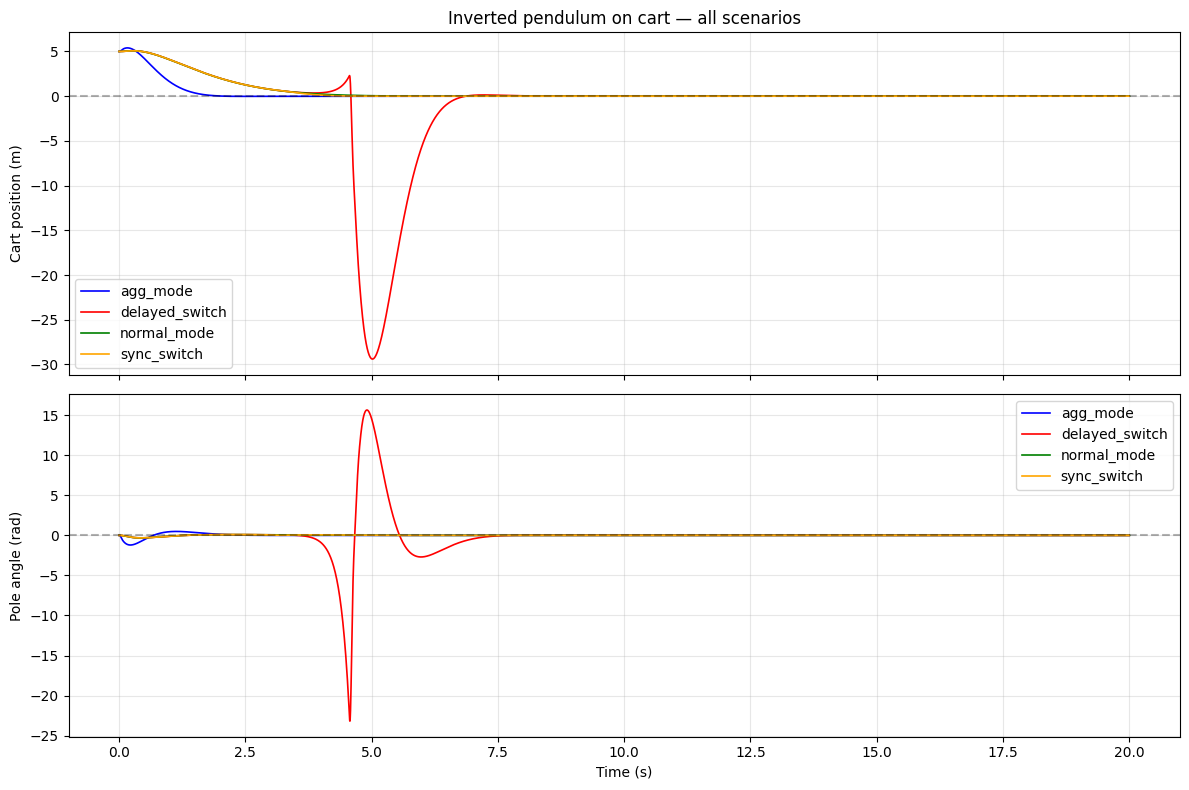

In [3]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

state_files = sorted(glob.glob('results/**/*_states.csv', recursive=True))
print(f"Found {len(state_files)} state files:")
for f in state_files:
    print(f"  {f}")

colors = ['blue', 'red', 'green', 'orange', 'purple']

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for i, state_file in enumerate(state_files):
    df = pd.read_csv(state_file)
    label = state_file.split('/')[-1].replace('_states.csv', '')
    c = colors[i % len(colors)]
    
    axes[0].plot(df['t'], df['p'], label=label, color=c, linewidth=1.2)
    axes[1].plot(df['t'], df['theta'], label=label, color=c, linewidth=1.2)

axes[0].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[0].set_ylabel('Cart position (m)')
axes[0].legend()
axes[0].set_title('Inverted pendulum on cart — all scenarios')
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[1].set_ylabel('Pole angle (rad)')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/all_scenarios_comparison.png', dpi=150, bbox_inches='tight')
plt.show()